# CALCUALTE
f(x) = $x_1^2$ + $x_2^2$ + $x_3^2$ + $x_4^2$ + $x_5^2$ + $x_6^2$

In [1]:
import random

# encoding
def generate_random_value(bound = 100):
    return (random.random()*2 - 1)*bound

# compute cost
def compute_cost(individual): # cost
    return sum(val*val for val in individual)

In [2]:
def create_individual():
    return [generate_random_value() for _ in range(n)]

def crossover(individual1, individual2, crossover_rate = 0.9):
    individual1_new = individual1.copy()
    individual2_new = individual2.copy()
    
    for i in range(n):
        if random.random() < crossover_rate:
            individual1_new[i] = individual2[i]
            individual2_new[i] = individual1[i]
            
    
    return individual1_new, individual2_new

def mutate(individual, mutation_rate = 0.05):
    individual_m = individual.copy()
    
    for i in range(n):
        if random.random() < mutation_rate:
            individual_m[i] = generate_random_value()
        
    return individual_m

def selection(sorted_old_population):    
    index1 = random.randint(0, m-1) 
    index2 = random.randint(0, m-1)
    
    while index2 == index1:
        index2 = random.randint(0, m-1)
            
    individual_s = sorted_old_population[index1]
    if index2 < index1: # get smaller one (cost)
        individual_s = sorted_old_population[index2]
    
    return individual_s 

In [3]:
n = 6
m = 100
n_generations = 300

losses = []

##### algorithm
# step 1: create initial population
population = [create_individual() for _ in range(m)]

#==== loops
elitism = 2
for i in range(n_generations):
    sorted_population = sorted(population, key=compute_cost)
        
    # for debug
    if i%10 == 0:
        losses.append(compute_cost(sorted_population[0]))
        print("Cost:", compute_cost(sorted_population[0]))
    
    # create new_population (get the first two)
    new_population = sorted_population[:elitism]   
    
    while len(new_population) < m:
        # selection
        individual_s1 = selection(sorted_population)
        individual_s2 = selection(sorted_population) # duplication
        
        # crossover
        individual_c1, individual_c2 = crossover(individual_s1, individual_s2)
        
        # mutation
        individual_m1 = mutate(individual_c1)
        individual_m2 = mutate(individual_c2)
        
        # copy 
        new_population.append(individual_m1)
        new_population.append(individual_m2)

    # update population
    population = new_population

Cost: 7768.020712925645
Cost: 867.5450053281535
Cost: 83.5914758551667
Cost: 32.79641375129269
Cost: 15.752149615497562
Cost: 15.399853392817882
Cost: 10.779704556705989
Cost: 3.1301106229982048
Cost: 0.9646261050427314
Cost: 0.9646261050427314
Cost: 0.7073137821801523
Cost: 0.7073137821801523
Cost: 0.7073137821801523
Cost: 0.7073137821801523
Cost: 0.464264273935814
Cost: 0.34462469034105075
Cost: 0.2878067192566388
Cost: 0.13635824813590064
Cost: 0.12614651928621684
Cost: 0.12614651928621684
Cost: 0.12614651928621684
Cost: 0.12614651928621684
Cost: 0.12614651928621684
Cost: 0.09178570225823793
Cost: 0.09178570225823793
Cost: 0.09178570225823793
Cost: 0.09178570225823793
Cost: 0.09178570225823793
Cost: 0.09178570225823793
Cost: 0.0756032937398092


# USING FITNESS

In [4]:
import random

# encoding
def generate_random_value(bound = 20):
    return (random.random()*2 - 1)*bound

# compute fitness
def compute_loss(individual):
    return sum(val*val for val in individual)

def compute_fitness(individual):
    return 1 / (0.0001 + compute_loss(individual))

In [5]:
def create_individual():
    return [generate_random_value() for _ in range(n)]

def crossover(individual1, individual2, crossover_rate = 0.9):
    individual1_new = individual1.copy()
    individual2_new = individual2.copy()
    
    for i in range(n):
        if random.random() < crossover_rate:
            individual1_new[i] = individual2[i]
            individual2_new[i] = individual1[i]
            
    
    return individual1_new, individual2_new

def mutate(individual, mutation_rate = 0.05):
    individual_m = individual.copy()
    
    for i in range(n):
        if random.random() < mutation_rate:
            individual_m[i] = generate_random_value()
        
    return individual_m

def selection(sorted_old_population):    
    index1 = random.randint(0, m-1) 
    index2 = random.randint(0, m-1)
    
    while index2 == index1:
        index2 = random.randint(0, m-1)
            
    individual_s = sorted_old_population[index1]
    if index2 > index1:
        individual_s = sorted_old_population[index2]
    
    return individual_s 

In [6]:
n = 6
m = 100
n_generations = 300

fitnesses = []

##### algorithm
# step 1: create initial population
population = [create_individual() for _ in range(m)]

#==== loops
elitism = 2
for i in range(n_generations):
    sorted_population = sorted(population, key=compute_fitness)
        
    # for debug
    if i%10 == 0:
        fitnesses.append(compute_fitness(sorted_population[-1]))
        print("loss:", compute_loss(sorted_population[-1]))
    
    # create new_population
    new_population = sorted_population[-elitism:]   
    
    while len(new_population) < m:
        # selection
        individual_s1 = selection(sorted_population)
        individual_s2 = selection(sorted_population) # duplication
        
        # crossover
        individual_c1, individual_c2 = crossover(individual_s1, individual_s2)
        
        # mutation
        individual_m1 = mutate(individual_c1)
        individual_m2 = mutate(individual_c2)
        
        # copy 
        new_population.append(individual_m1)
        new_population.append(individual_m2)

    # update population
    population = new_population

loss: 245.2083105822982
loss: 29.16587709021171
loss: 1.3952118726817595
loss: 0.19659356116808643
loss: 0.08137345474132748
loss: 0.07645988115003252
loss: 0.07241610766385992
loss: 0.06634083822927134
loss: 0.06634083822927134
loss: 0.06634083822927134
loss: 0.06634083822927134
loss: 0.021449279989997967
loss: 0.011772421388900717
loss: 0.011772421388900717
loss: 0.011303473740115434
loss: 0.011303473740115434
loss: 0.011303473740115434
loss: 0.009883473697955487
loss: 0.008894417722339301
loss: 0.008894417722339301
loss: 0.008894417722339301
loss: 0.0012614331510479755
loss: 0.0012614331510479755
loss: 0.0012614331510479755
loss: 0.0012614331510479755
loss: 0.0012614331510479755
loss: 0.0012614331510479755
loss: 0.0012614331510479755
loss: 0.0012614331510479755
loss: 0.0012614331510479755


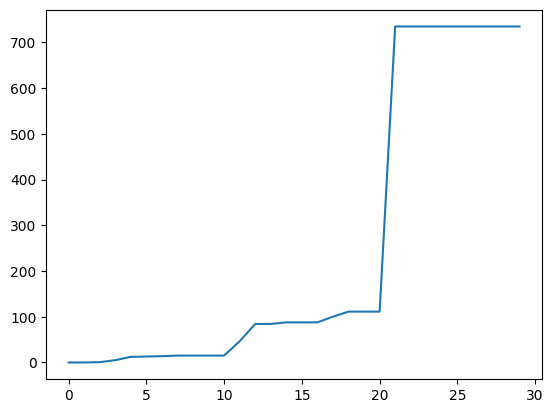

In [7]:
import matplotlib.pyplot as plt

plt.plot(fitnesses)
plt.show()

In [8]:
sorted_population = sorted(population, key=compute_fitness)
print(sorted_population[-1])

[-0.004812743480950843, 0.0021933090603809546, 0.006916373608079063, 0.02129241553458172, 0.015223508167809818, 0.022371894476798104]


In [9]:
print(sorted_population[0])

[-0.004812743480950843, 0.0021933090603809546, 19.989646561950334, 0.02129241553458172, 0.015223508167809818, 0.022371894476798104]
